# Notebook 1: Baboon data

**Formål:** Udforsk bavian datasættet, identificer populationer, beregn summary statistics (heterozygositet, SFS) og forbered subsets til brug i efterfølgende coalescent modeller.

**Datasæt:** Hele-genomsekvenser fra 225 vilde bavianer fordelt på 6 arter og 19 geografiske lokaliteter (Sørensen et al., *Science* 2023).


## Indholdsfortegnelse
1. [Indlæs data](#1-indlæs-data)
2. [Udforsk samples og populationer](#2-udforsk-samples-og-populationer)
3. [Udvælg populationer til analyse](#3-udvælg-populationer-til-analyse)
4. [Beregn allele counts per population](#4-beregn-allele-counts-per-population)
5. [Site Frequency Spectrum (SFS)](#5-site-frequency-spectrum-sfs)
6. [Heterozygositet per population](#6-heterozygositet-per-population)
7. [Fold SFS og visualisering](#7-fold-sfs-og-visualisering)
8. [Gem data til efterfølgende notebooks](#8-gem-data-til-efterfølgende-notebooks)

In [1]:
# Importer nødvendige pakker
# phasic importeres først for at sætte JAX-backend korrekt
from phasic import Graph, with_ipv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sgkit as sg
from pathlib import Path
%config InlineBackend.figure_format = 'svg'
from vscodenb import set_vscode_theme

np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

# Sti til data
DATA_DIR = Path("/faststorage/project/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021_ZARR")

# Output-mappe til gemte data
OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)

print("Imports OK")

Imports OK


## 1. Indlæs data

Jeg indlæser kromosom 20 som udgangspunkt. Det er et mellemstort kromosom og godt til at teste koden på.
Skift til andre kromosomer eller kombiner dem senere efter behov.

In [2]:
# Indlæs chr20
ds = sg.load_dataset(DATA_DIR / "chr20.phased.rehead.vcz")
print(ds)


<xarray.Dataset> Size: 3GB
Dimensions:               (variants: 2665269, samples: 227, ploidy: 2,
                           contigs: 1, filters: 1, region_index_values: 2666,
                           region_index_fields: 6, alt_alleles: 1, alleles: 2)
Dimensions without coordinates: variants, samples, ploidy, contigs, filters,
                                region_index_values, region_index_fields,
                                alt_alleles, alleles
Data variables: (12/19)
    call_genotype         (variants, samples, ploidy) int8 1GB dask.array<chunksize=(1000, 227, 2), meta=np.ndarray>
    call_genotype_mask    (variants, samples, ploidy) bool 1GB dask.array<chunksize=(1000, 227, 2), meta=np.ndarray>
    call_genotype_phased  (variants, samples) bool 605MB dask.array<chunksize=(1000, 227), meta=np.ndarray>
    contig_id             (contigs) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    filter_description    (filters) object 8B dask.array<chunksize=(1,), meta=np.ndar

In [3]:
# Antal varianter og samples
n_variants = ds.dims["variants"]
n_samples  = ds.dims["samples"]
print(f"Antal varianter: {n_variants:,}")
print(f"Antal samples:   {n_samples}")

Antal varianter: 2,665,269
Antal samples:   227


/tmp/ipykernel_2522853/1356574667.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_variants = ds.dims["variants"]
/tmp/ipykernel_2522853/1356574667.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_samples  = ds.dims["samples"]


## 2. Udforsk samples og populationer

Jeg lister alle sample-ID'er og kortlægger dem til arter og lokaliteter.
Sample-ID'erne følger mønsteret `PD_XXXX`. Artsinformation hentes fra en metadata-tabel.

In [4]:
# Liste over alle samples
sample_ids = ds['sample_id'].values
print(f"Første 10 samples: {sample_ids[:10]}")
print(f"Totalt {len(sample_ids)} samples")

Første 10 samples: ['Sci_16066' 'Sci_16098' 'Sci_30877' 'Sci_30977' 'Sci_34449' 'Sci_34474'
 'Sci_38168' 'Sci_97074' 'Sci_97124' 'PD_0067']
Totalt 227 samples


In [10]:
# Definer populationer manuelt
# Udfylder med de korrekte sample-ID'er fra Tabel S2 i artiklen eller fra ds['sample_id'].values ovenfor.

population_map = {
    # Art               : [sample IDs]                                                           : Navn
    "yellow_east_mikumi":  ['PD_0268', 'PD_0269','PD_0270', 
                            'PD_0271', 'PD_0272', 'PD_0637',
                            'PD_0687', 'PD_0688','PD_0689', 'PD_0690',
                            'PD_0691', 'PD_0745', 'PD_0746', 'PD_0747',
                            'PD_0748', 'PD_0752', 'PD_0753', 'PD_0754', 
                            'PD_0755','PD_0756', 'PD_0761', 'PD_0762',
                            'PD_0763', 'PD_0764', 'PD_0765','PD_0766',
                            'PD_0767','PD_0768', 'PD_0769','PD_0770',
                            'PD_0771', 'PD_0772', 'PD_0773', 'PD_0774','PD_0775'],               # P. cynocephalus, Mikumi
    "yellow_east_ruaha":   ['PD_0213', 'PD_0214', 'PD_0215', 'PD_0216', 'PD_0217', 'PD_0503'],   # P. cynocephalus, Ruaha
    "yellow_west_mahale":  ['PD_0228','PD_0229','PD_0230', 'PD_0231',
                            'PD_0232','PD_0233','PD_0234', 'PD_0658', 'PD_0659'],                # P. cynocephalus, Mahale/Katavi
    "kinda":               ['PD_0749','PD_0750','PD_0751', 'PD_0758', 'PD_0759', 'PD_0760',
                            'PD_0776', 'PD_0777', 'PD_0778', 'PD_0779', 'PD_0780', 'PD_0781',
                            'PD_0782', 'PD_0783', 'PD_0784', 'PD_0785', 'PD_0786', 'PD_0787',
                            'PD_0788', 'PD_0789', 'PD_0790', 'PD_0791', 'PD_0792', 'PD_0793',
                            'PD_0794_BAB', 'PD_0692', 'PD_0693', 'PD_0694', 'PD_0695'],          # P. kindae, Chunga/Dendro Park
    "olive_south":         ['PD_0199', 'PD_0200', 'PD_0201', 'PD_0202', 'PD_0203', 'PD_0208',
                            'PD_0209', 'PD_0210', 'PD_0211', 'PD_0212', 'PD_0238', 'PD_0239',
                            'PD_0240', 'PD_0241', 'PD_0242', 'PD_0243', 'PD_0244', 'PD_0265',
                            'PD_0266','PD_0267', 'PD_0492', 'PD_0493', 'PD_0494', 'PD_0495', 
                            'PD_0496', 'PD_0497', 'PD_0498', 'PD_0499', 'PD_0500', 'PD_0501',
                            'PD_0502', 'PD_0641', 'PD_0642', 'PD_0674', 'PD_0675', 'PD_0676',
                            'PD_0677', 'PD_0678', 'PD_0679', 'PD_0680', 'PD_0681', 'PD_0682',
                            'PD_0683', 'PD_0684', 'PD_0685', 'PD_0686'],                         # P. anubis, Tanzania (Lake Manyara, Ngorongoro, Serengeti, Tarangire)
    "olive_gog":           ['PD_0719', 'PD_0720', 'PD_0721', 'PD_0722', 'PD_0723', 'PD_0724',
                            'PD_0725', 'PD_0726', 'PD_0727', 'PD_0728', 'PD_0729', 'PD_0730',
                            'PD_0731', 'PD_0732', 'PD_0733', 'PD_0734', 'PD_0735', 'PD_0736',
                            'PD_0737', 'PD_0738' 'PD_0739', 'PD_0740', 'PD_0741', 'PD_0742',
                            'PD_0743', 'PD_0744'],                                              # P. anubis, Gog (Ethiopia)
}

# Eksempel på hvordan du kan printe alle sample-ID'er for at identificere dem:
for sid in sample_ids:
    print(sid)

Sci_16066
Sci_16098
Sci_30877
Sci_30977
Sci_34449
Sci_34474
Sci_38168
Sci_97074
Sci_97124
PD_0067
PD_0199
PD_0200
PD_0201
PD_0202
PD_0203
PD_0204
PD_0205
PD_0206
PD_0207
PD_0208
PD_0209
PD_0210
PD_0211
PD_0212
PD_0213
PD_0214
PD_0215
PD_0216
PD_0217
PD_0218
PD_0219
PD_0220
PD_0221
PD_0222
PD_0223
PD_0224
PD_0225
PD_0226
PD_0227
PD_0228
PD_0229
PD_0230
PD_0231
PD_0232
PD_0233
PD_0234
PD_0235
PD_0236
PD_0237
PD_0238
PD_0239
PD_0240
PD_0241
PD_0242
PD_0243
PD_0244
PD_0265
PD_0266
PD_0267
PD_0268
PD_0269
PD_0270
PD_0271
PD_0272
PD_0390
PD_0391
PD_0392
PD_0393
PD_0394
PD_0395
PD_0396
PD_0397
PD_0398
PD_0399
PD_0400
PD_0401
PD_0492
PD_0493
PD_0494
PD_0495
PD_0496
PD_0497
PD_0498
PD_0499
PD_0500
PD_0501
PD_0502
PD_0503
PD_0504
PD_0505
PD_0506
PD_0507
PD_0508
PD_0509
PD_0637
PD_0641
PD_0642
PD_0649
PD_0650
PD_0651
PD_0652
PD_0653
PD_0654
PD_0658
PD_0659
PD_0662
PD_0674
PD_0675
PD_0676
PD_0677
PD_0678
PD_0679
PD_0680
PD_0681
PD_0682
PD_0683
PD_0684
PD_0685
PD_0686
PD_0687
PD_0688
PD_0689
PD_069

In [11]:
# Laver en metadata dataframe
rows = []
for pop, ids in population_map.items():
    for sid in ids:
        rows.append({"sample_id": sid, "population": pop})

meta = pd.DataFrame(rows)
print(meta.groupby("population").size().rename("n_samples"))

population
kinda                 29
olive_gog             25
olive_south           46
yellow_east_mikumi    35
yellow_east_ruaha      6
yellow_west_mahale     9
Name: n_samples, dtype: int64


## 3. Udvælg populationer til analyse

Til de efterfølgende two-island og IM-modeller fokuserer jeg på:
- **Eastern yellow baboons** (Mikumi) — veldefineret population
- **Western yellow baboons** (Mahale/Katavi) — hybrid population, særlig interessant
- **Kinda baboons** — tæt relateret til western yellow
- **Southern olive baboons** — genflow med eastern yellow dokumenteret i artiklen

Jeg starter med et parvist subset for two-island modellen.

In [12]:
def extract_population(ds, sample_ids_list):
    """
    Udtrækker et subset af datasættet for en given liste af sample-ID'er.
    Returnerer et nyt xarray Dataset.
    """
    mask = ds["sample_id"].isin(sample_ids_list).values
    return ds.isel(samples=mask)


# Eksempel: eastern yellow baboons
ds_yellow_east = extract_population(ds, population_map["yellow_east_mikumi"])
print(f"Eastern yellow: {ds_yellow_east.dims['samples']} samples")

# Eksempel: Kinda baboons
ds_kinda = extract_population(ds, population_map["kinda"])
print(f"Kinda: {ds_kinda.dims['samples']} samples")

Eastern yellow: 35 samples
Kinda: 29 samples


/tmp/ipykernel_2522853/3496395125.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Eastern yellow: {ds_yellow_east.dims['samples']} samples")
/tmp/ipykernel_2522853/3496395125.py:16: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Kinda: {ds_kinda.dims['samples']} samples")


## 4. Beregn allele counts per population

Jeg beregner derived variant counts (singletons, doubletons, osv.) for hver population.
Disse counts danner grundlaget for SFS analysen og for at fitte coalescent modeller.

In [13]:
def compute_derived_counts(ds_pop, pop_name="population"):
    """
    Beregner derived allele counts for en population.
    Returnerer en DataFrame med position, derived_count og nr_samples.
    """
    vac = sg.count_variant_alleles(ds_pop)
    ac  = vac["variant_allele_count"].values  # shape: (variants, alleles)
    
    nr_samples    = ac.sum(axis=1)   # totalt antal haplotyper
    derived_count = ac[:, 1]         # antal kopier af det derived allel
    
    df = pd.DataFrame({
        "position":      ds_pop["variant_position"].values,
        "derived_count": derived_count,
        "nr_samples":    nr_samples,
    })
    
    # Behold kun SNPs med mindst et derived allel
    df = df[(df["derived_count"] > 0) & (df["derived_count"] < df["nr_samples"])]
    
    print(f"{pop_name}: {len(df):,} segregerende SNPs")
    return df


df_yellow_east = compute_derived_counts(ds_yellow_east, "Eastern yellow")
df_kinda       = compute_derived_counts(ds_kinda,       "Kinda")

df_yellow_east.head()

Eastern yellow: 868,037 segregerende SNPs
Kinda: 947,644 segregerende SNPs


,position,derived_count,nr_samples
1,73,7,70
4,149,13,70
7,283,49,70
8,437,5,70
10,471,7,70


## 5. Site Frequency Spectrum (SFS)

SFS tæller, hvor mange SNPs der er observeret med 1 kopi, 2 kopier, ..., n-1 kopier af det derived allel.
Formen af SFS afspejler populationshistorien fx. viser en overvægt af singletons tegn på vækst eller selektion.

Jeg bruger den unfoldede SFS (jeg antager, at allel 1 er det derived/afledte allel, hvilket forudsætter korrekt polarisering).

In [14]:
def compute_sfs(df, pop_name="population"):
    """
    Beregner den unfoldede SFS for én population.
    Forudsætter at alle sites har samme nr_samples (bruges max).
    """
    n = int(df["nr_samples"].max())   # haploid sample size
    counts = np.zeros(n + 1, dtype=int)
    
    for k, grp in df.groupby("derived_count"):
        if 0 < k < n:
            counts[k] = len(grp)
    
    sfs = pd.Series(counts[1:n], index=range(1, n), name=pop_name)
    return sfs


sfs_yellow_east = compute_sfs(df_yellow_east, "Eastern yellow")
sfs_kinda       = compute_sfs(df_kinda,       "Kinda")

print(sfs_yellow_east.head(10))

1     133084
2      82780
3      57377
4      45959
5      39250
6      31387
7      29371
8      24856
9      21101
10     18544
Name: Eastern yellow, dtype: int64


## 6. Heterozygositet per population

Gennemsnitlig heterozygositet (π) per base-par er et klassisk mål for genetisk diversitet.
Artiklen rapporterer heterozygositet fra 0.0006–0.0029 på tværs af de 19 lokaliteter.

In [15]:
def compute_pi(df):
    """
    Beregner gennemsnitlig nukleotiddiversitet (π) per site.
    π = Σ [ (k/n) * ((n-k)/n) * 2 ] / L
    hvor k = derived count, n = nr haploid samples, L = antal sites.
    """
    k = df["derived_count"].values
    n = df["nr_samples"].values
    
    # Heterozygositet per site (forventet frekvens af het. par)
    het_per_site = 2 * (k / n) * ((n - k) / n)
    
    # Totalt antal sites (hele kromosomet, inkl. monomorfe)
    L = int(df["position"].max() - df["position"].min())
    
    pi = het_per_site.sum() / L
    return pi


pi_vals = {}
for name, df_pop in [
    ("Eastern yellow", df_yellow_east),
    ("Kinda",          df_kinda),
]:
    pi_vals[name] = compute_pi(df_pop)

pi_df = pd.DataFrame.from_dict(pi_vals, orient="index", columns=["pi"])
print(pi_df.round(6))
# Forventet: ~ 0.0006–0.0026 jf. artiklen

                      pi
Eastern yellow  0.002584
Kinda           0.002861


## 7. Fold SFS og visualisering

Den foldede SFS bruges når jeg ikke er sikre på polariseringen (ancestral vs. derived).
Den folder SFS'en ved midten, så jeg kun ser minor allele frequencies.

Jeg plotter begge SFS'er for eastern yellow og Kinda baboons.

In [16]:
def fold_sfs(sfs):
    """
    Folder en unfoldet SFS.
    For n haplotyper: foldet SFS har indeks 1..floor(n/2).
    """
    n = len(sfs) + 1  # antal haplotyper
    mid = n // 2
    folded = sfs.copy().astype(float)
    
    # Fold: summer spejlede bins
    for i in range(1, mid):
        folded.iloc[i - 1] = sfs.iloc[i - 1] + sfs.iloc[n - i - 1]
    
    # Behold kun første halvdel (1..mid)
    return folded.iloc[:mid]


sfs_yellow_east_folded = fold_sfs(sfs_yellow_east)
sfs_kinda_folded       = fold_sfs(sfs_kinda)

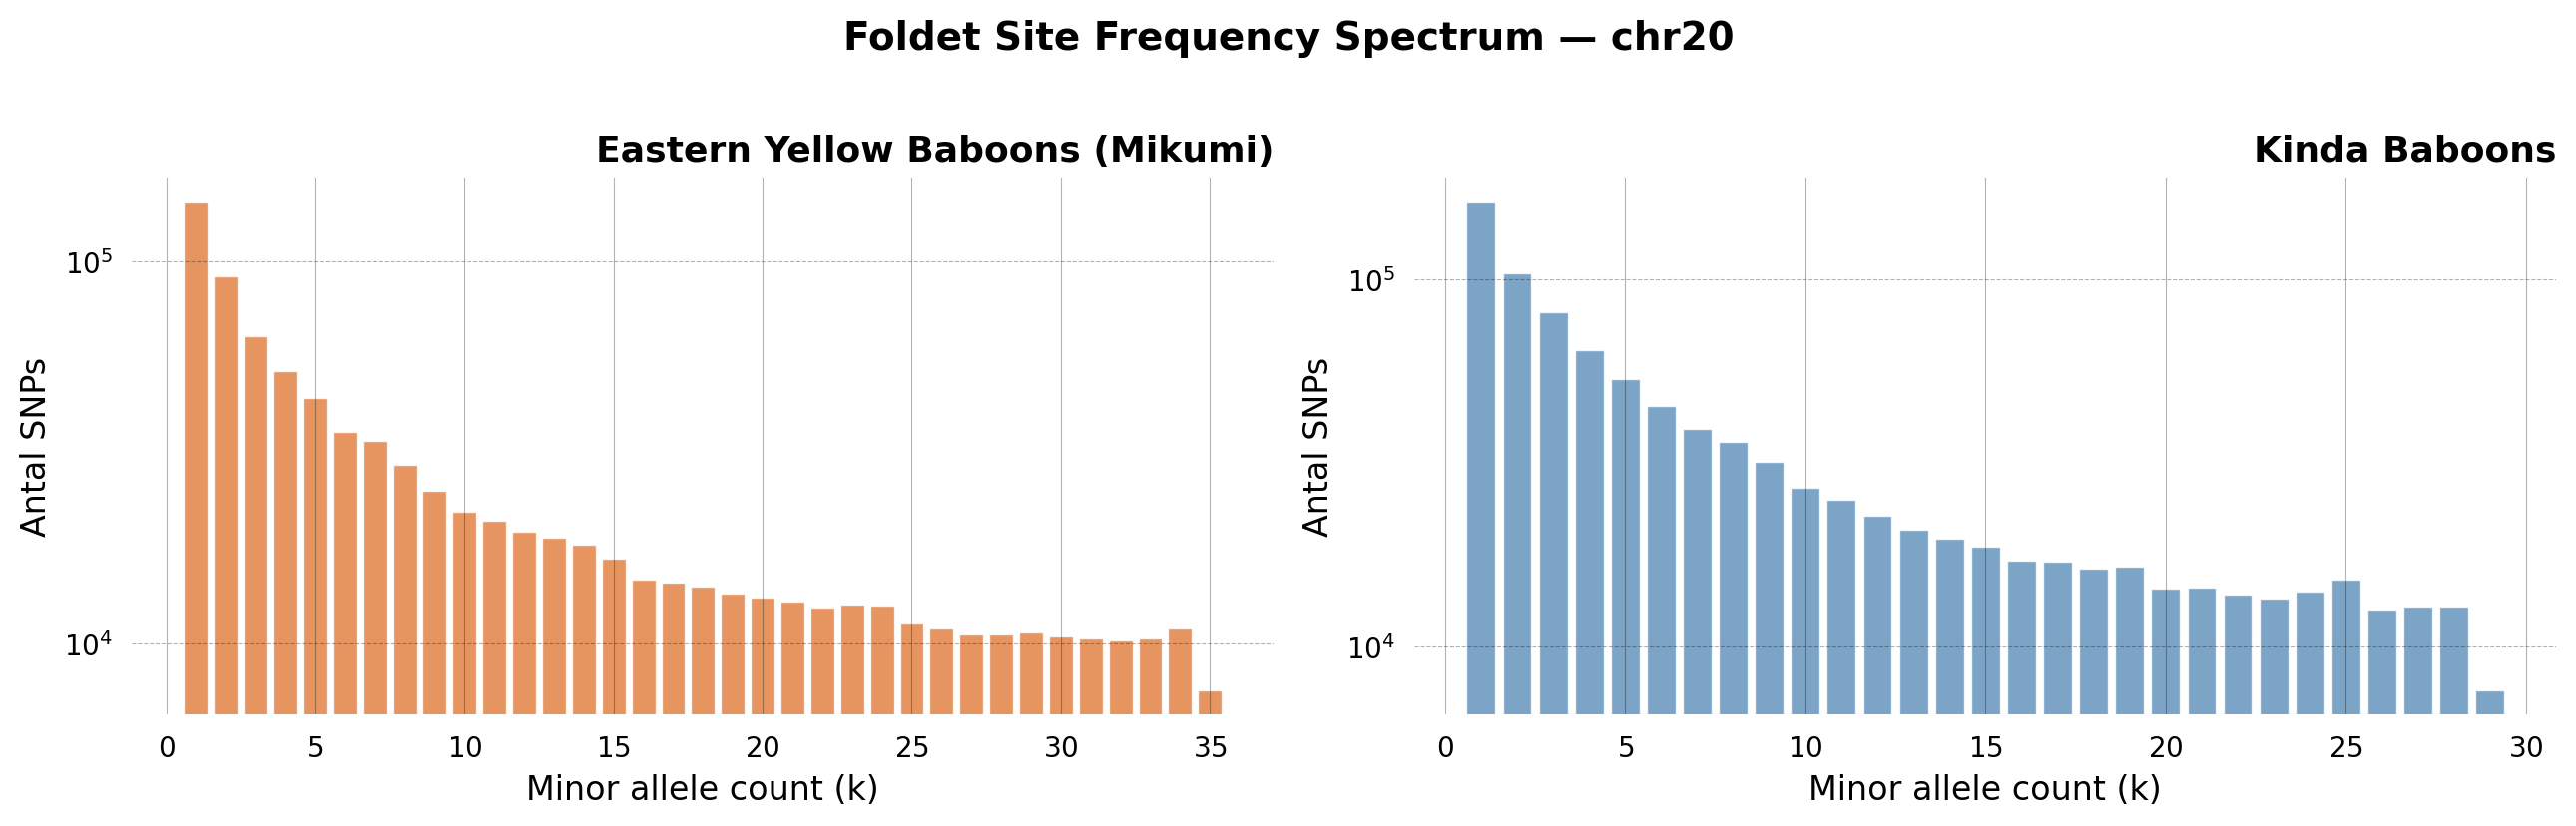

Figur gemt: output/sfs_comparison.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

populations = [
    (sfs_yellow_east_folded, "Eastern Yellow Baboons (Mikumi)", "#E07B39"),
    (sfs_kinda_folded,       "Kinda Baboons",                   "#5B8DB8"),
]

for ax, (sfs, title, color) in zip(axes, populations):
    freqs = np.arange(1, len(sfs) + 1)
    ax.bar(freqs, sfs.values, color=color, alpha=0.8, edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Minor allele count (k)", fontsize=12)
    ax.set_ylabel("Antal SNPs", fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_yscale("log")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Foldet Site Frequency Spectrum — chr20", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "sfs_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figur gemt: output/sfs_comparison.png")

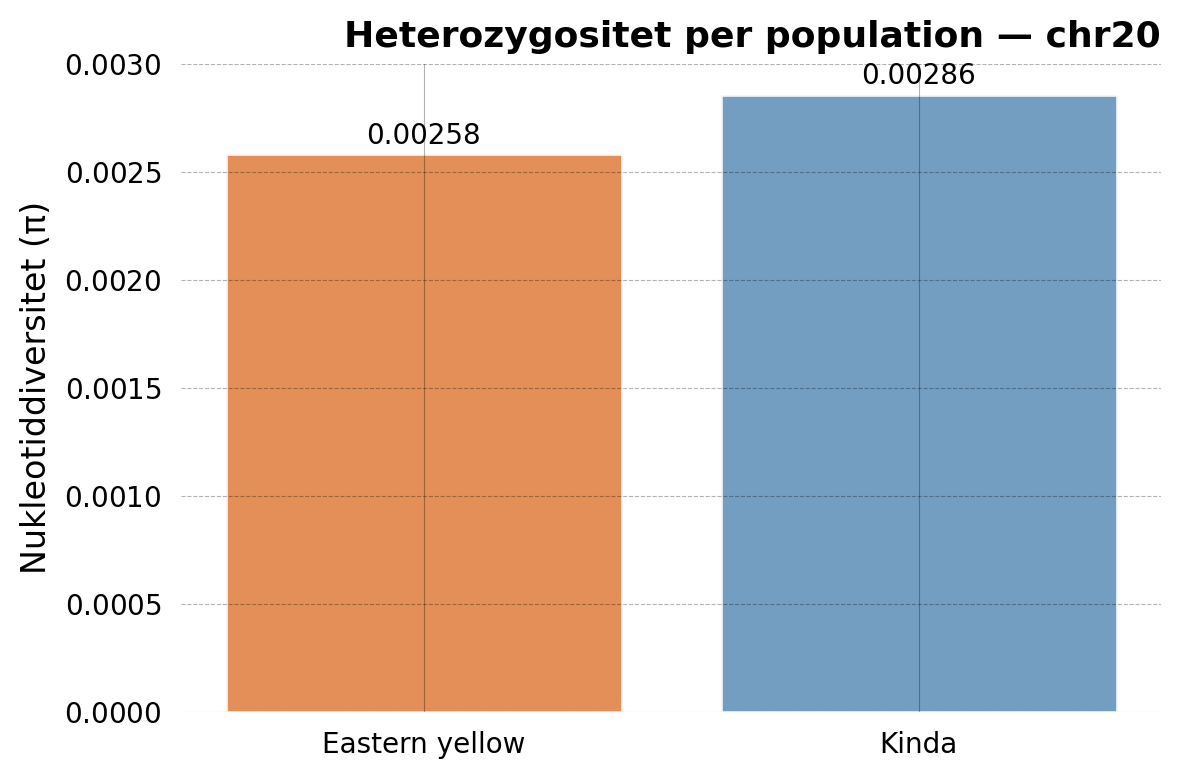

In [18]:
# Sammenligning af heterozygositet
fig, ax = plt.subplots(figsize=(6, 4))

colors = ["#E07B39", "#5B8DB8"]
pops   = list(pi_vals.keys())
vals   = list(pi_vals.values())

bars = ax.bar(pops, vals, color=colors, alpha=0.85, edgecolor="white")
ax.set_ylabel("Nukleotiddiversitet (π)", fontsize=12)
ax.set_title("Heterozygositet per population — chr20", fontsize=13, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3, linestyle="--")

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.00002,
            f"{val:.5f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR / "heterozygosity.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Gem data til efterfølgende notebooks

Jeg gemmer de beregnede DataFrames som CSV-filer, så Notebook 2 (two-island model) kan indlæse dem direkte uden at genkøre hele datapipelinen.

In [19]:
# Gem derived counts DataFrames
df_yellow_east.to_csv(OUT_DIR / "derived_counts_yellow_east.csv", index=False)
df_kinda.to_csv(OUT_DIR       / "derived_counts_kinda.csv",       index=False)

# Gem foldede SFS'er
sfs_yellow_east_folded.to_csv(OUT_DIR / "sfs_folded_yellow_east.csv", header=True)
sfs_kinda_folded.to_csv(OUT_DIR       / "sfs_folded_kinda.csv",       header=True)

# Gem heterozygositet
pi_df.to_csv(OUT_DIR / "pi_per_population.csv")

print("Alle filer gemt i output/")
for f in sorted(OUT_DIR.iterdir()):
    print(" ", f.name)

Alle filer gemt i output/
  derived_counts_kinda.csv
  derived_counts_yellow_east.csv
  heterozygosity.png
  pi_per_population.csv
  sfs_comparison.png
  sfs_folded_kinda.csv
  sfs_folded_yellow_east.csv


## Opsummering

I denne notebook har vi:

1. **Indlæst** chr20-datasættet med sgkit
2. **Kortlagt** sample-ID'er til populationer baseret på Sørensen et al. 2023
3. **Udtrukket** population-subsets med `isel(samples=mask)`
4. **Beregnet** derived allele counts per population
5. **Beregnet** unfoldet og foldet SFS
6. **Estimeret** nukleotiddiversitet π per population
7. **Visualiseret** og **gemt** resultater til brug i Notebook 2

### Næste skridt: Notebook 2 — Two-island model
Vi bruger de gemte SFS-data til at fitte en to-populations coalescent-model i **Phasic**, der modellerer migration mellem fx eastern yellow baboons og Kinda baboons.